In [ ]:
classification + localization

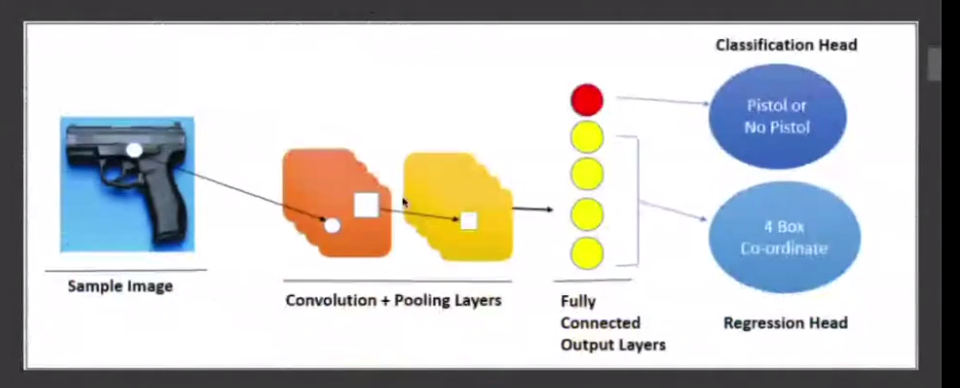

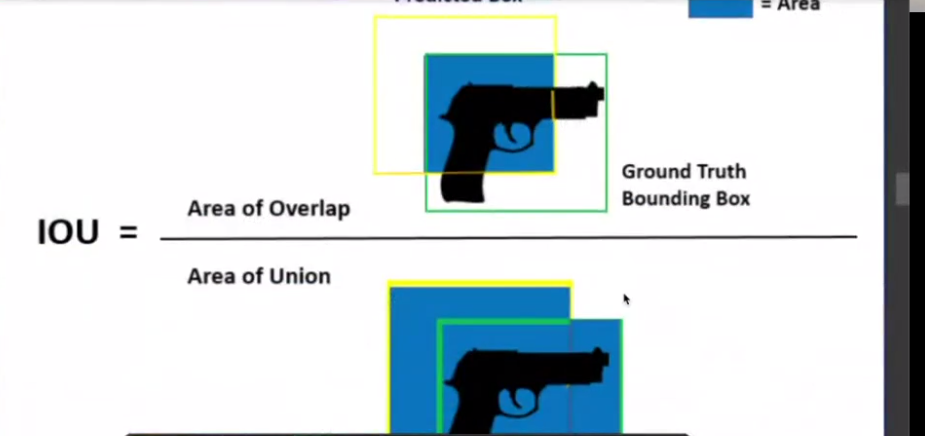

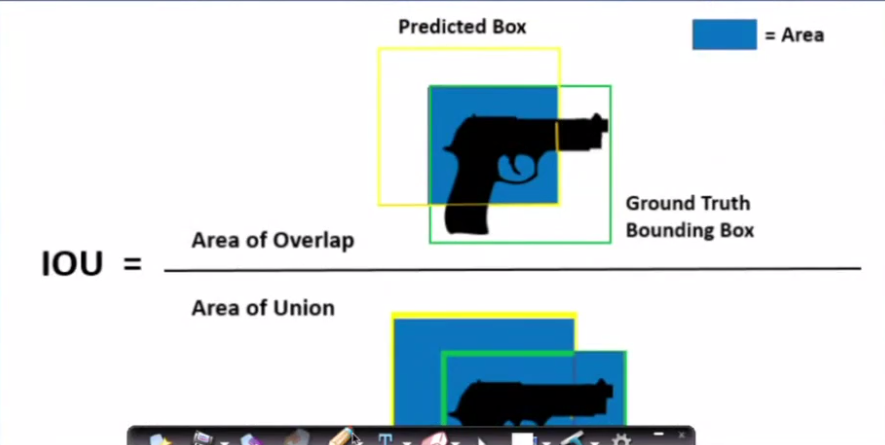

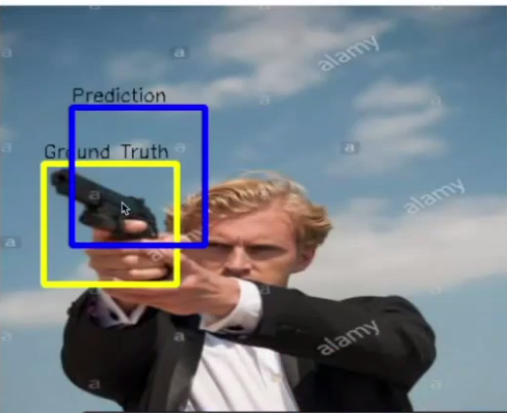

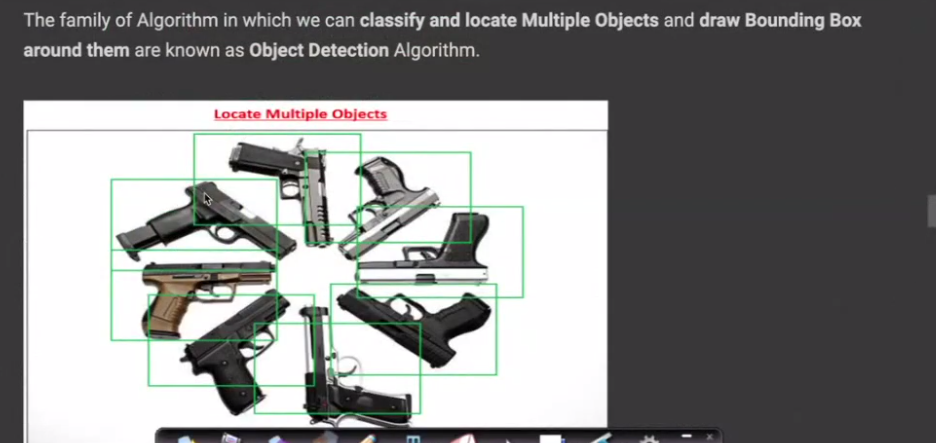

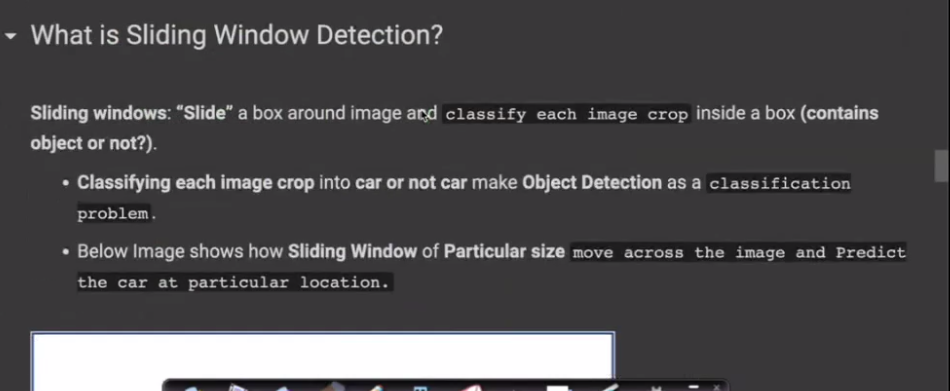

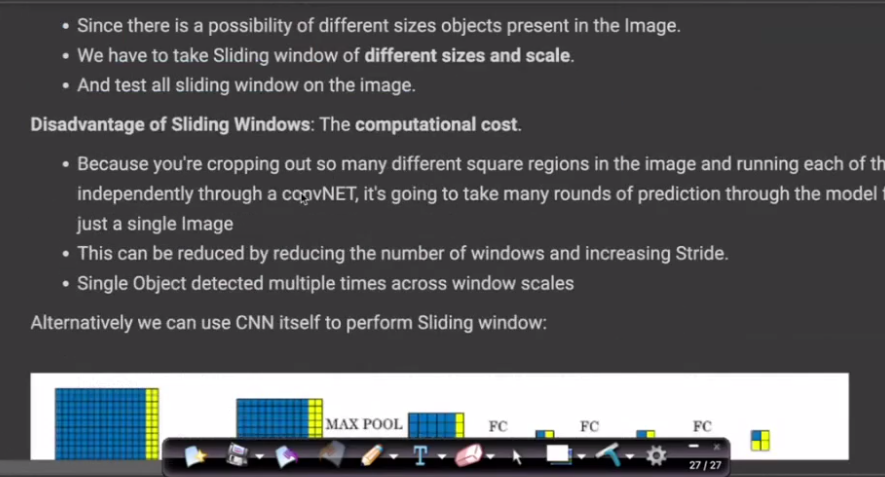

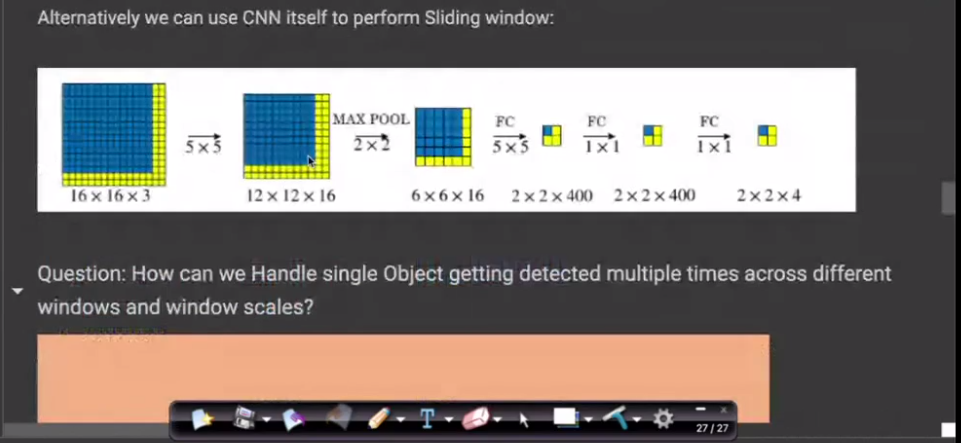

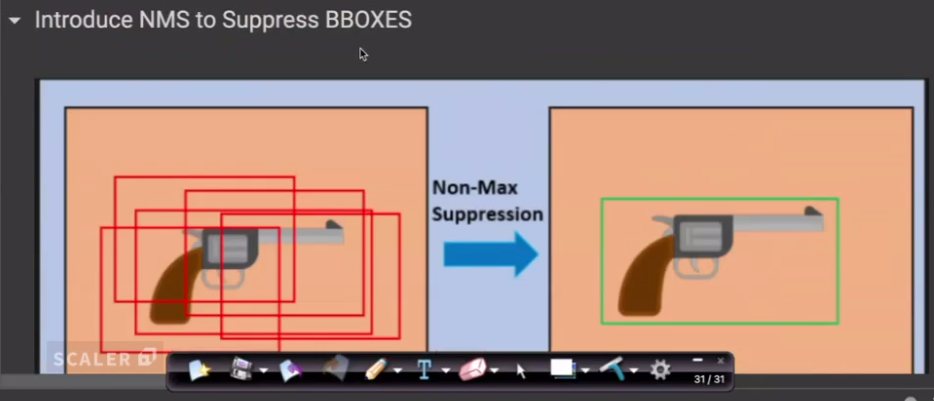

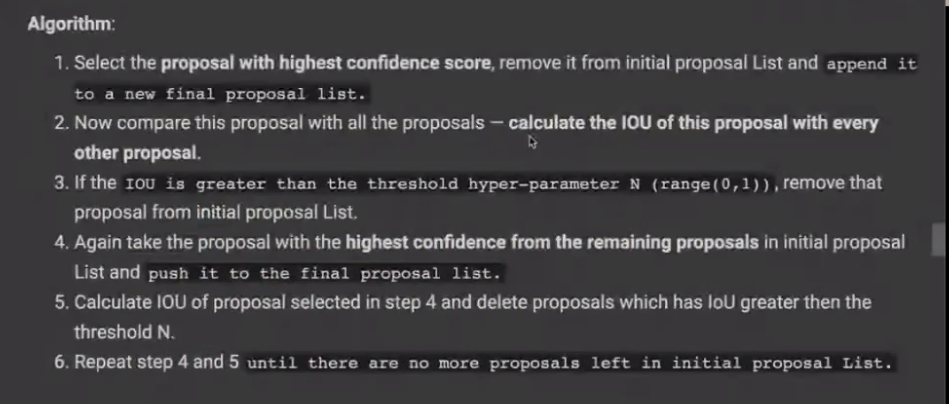

### What is Non-Maximum Suppression (NMS)?

In object detection tasks in computer vision, a model often predicts multiple bounding boxes for the same object, especially when the object is detected by different parts of the model or at various scales. Non-Maximum Suppression (NMS) is a post-processing technique used to eliminate these redundant overlapping bounding boxes, keeping only the most confident detection for each object.

#### Why is NMS needed?

1.  **Redundant Detections**: Object detection models often generate many bounding box proposals, and multiple proposals might highly overlap with each other, all pointing to the same object.
2.  **Improved Clarity**: Without NMS, the output would be cluttered with many boxes around a single object, making it difficult to interpret the actual detections.

#### How NMS Works (General Workflow):

1.  **Input**: A list of bounding boxes, each with an associated confidence score (indicating how likely it is that the box contains an object) and its coordinates (e.g., `[x1, y1, x2, y2]`).
2.  **Sorting**: The bounding boxes are sorted in descending order based on their confidence scores.
3.  **Selection**: The box with the highest score is selected and added to the final list of detections.
4.  **Suppression**: All other boxes that significantly overlap with the selected box (typically measured by Intersection over Union, or IoU, exceeding a certain threshold) are suppressed (removed from consideration).
5.  **Iteration**: Steps 3 and 4 are repeated until no more boxes are left to process in the original list.
6.  **Output**: The final list of non-overlapping, high-confidence bounding boxes.

In [ ]:
import numpy as np

def calculate_iou(box1, box2):
    """Calculates the Intersection over Union (IoU) of two bounding boxes."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection_area = max(0, x2 - x1) * max(0, y2 - y1)

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = float(box1_area + box2_area - intersection_area)

    return intersection_area / union_area if union_area > 0 else 0.0

def nms(boxes, scores, iou_threshold):
    """Performs Non-Maximum Suppression (NMS)."""
    if len(boxes) == 0:
        return []

    # Convert to numpy arrays for easier manipulation
    boxes = np.array(boxes)
    scores = np.array(scores)

    # Get the indices of boxes sorted by score in descending order
    order = scores.argsort()[::-1]

    keep = []
    while order.size > 0:
        # Pick the box with the highest score
        idx = order[0]
        keep.append(idx)

        # Get the highest scoring box
        current_box = boxes[idx]

        # Calculate IoU with all other remaining boxes
        ious = [calculate_iou(current_box, boxes[o]) for o in order[1:]]

        # Find indices of boxes to keep (IoU below threshold)
        # Note: order[1:] corresponds to the boxes we compared against
        remaining_indices_to_keep = np.where(np.array(ious) < iou_threshold)[0]

        # Update order to only include boxes that were not suppressed
        order = order[remaining_indices_to_keep + 1] # +1 because we skipped the first element of `order`

    return keep

# Example Usage:
# Bounding boxes in format [x1, y1, x2, y2]
boxes = [
    [10, 10, 70, 70],  # Box 1
    [20, 20, 80, 80],  # Box 2 (high overlap with Box 1)
    [15, 15, 75, 75],  # Box 3 (high overlap with Box 1/2)
    [100, 100, 150, 150], # Box 4 (no overlap)
    [105, 105, 160, 160]  # Box 5 (high overlap with Box 4)
]

scores = [
    0.9,  # Score for Box 1
    0.85, # Score for Box 2
    0.92, # Score for Box 3
    0.7,  # Score for Box 4
    0.75  # Score for Box 5
]

iou_threshold = 0.5

selected_indices = nms(boxes, scores, iou_threshold)

print("Original Boxes and Scores:")
for i, (box, score) in enumerate(zip(boxes, scores)):}
    print(f"Box {i}: {box}, Score: {score:.2f}")

print(f"\nSelected Boxes after NMS (IoU threshold = {iou_threshold}):")
for i in selected_indices:
    print(f"Box {i}: {boxes[i]}, Score: {scores[i]:.2f}")

#### Explanation of the NMS Code Example:

1.  **`calculate_iou(box1, box2)` function**: This helper function computes the Intersection over Union (IoU) between two bounding boxes. IoU is a common metric to quantify the overlap between two bounding boxes.
    *   It determines the coordinates of the intersection rectangle.
    *   It calculates the area of intersection.
    *   It calculates the area of each individual box.
    *   It then computes the union area (sum of individual areas minus intersection area).
    *   Finally, it returns the ratio of intersection area to union area.

2.  **`nms(boxes, scores, iou_threshold)` function**: This is the core NMS implementation.
    *   **Input**: Takes a list of `boxes` (each `[x1, y1, x2, y2]`), a list of `scores` corresponding to each box, and an `iou_threshold`.
    *   **Initialization**: Converts `boxes` and `scores` to NumPy arrays for efficient array operations. It then sorts the box indices based on their `scores` in descending order. This ensures we process the most confident boxes first.
    *   **`while order.size > 0` loop**: This loop continues as long as there are boxes left to process.
        *   **`idx = order[0]`**: Selects the index of the box with the highest confidence among the remaining boxes.
        *   **`keep.append(idx)`**: Adds this box's index to our `keep` list, as it's a valid detection.
        *   **`current_box = boxes[idx]`**: Retrieves the coordinates of the selected highest-scoring box.
        *   **`ious = [...]`**: Calculates the IoU between `current_box` and all other *remaining* boxes (those in `order[1:]`).
        *   **`remaining_indices_to_keep = np.where(np.array(ious) < iou_threshold)[0]`**: This is the suppression step. It finds the indices of the boxes among the `order[1:]` set whose IoU with `current_box` is *less than* the `iou_threshold`. These are the boxes that *do not* significantly overlap with `current_box` and thus are candidates for future selection.
        *   **`order = order[remaining_indices_to_keep + 1]`**: Updates the `order` array. We add `+1` to `remaining_indices_to_keep` because `ious` was calculated against `order[1:]`, so the indices from `np.where` are relative to `order[1:]`, not the full `order`.
    *   **Output**: Returns the `keep` list, containing the indices of the selected, non-overlapping bounding boxes.

3.  **Example Usage**: Demonstrates how to use the `nms` function with sample bounding boxes and scores. You can see how boxes with high overlap but lower scores are suppressed, while confident, non-overlapping boxes are kept.